In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
rng = np.random.default_rng(15)

n= 150

advertising = rng.normal(50,12,n)
visitors =  400 + 8 * advertising+ rng.normal(0,80,n)

conversion_rate = rng.normal(0.12, 0.02, n)

buyers = visitors*conversion_rate + rng.normal(0,5,n)

sales= 20+0.7*advertising+0.35*buyers+rng.normal(0,8,n)

satisfaction = 3.0 + 0.006*sales+rng.normal(0,0.35,n)

channel= rng.choice(
    ['Online','Offline'], size=n
)


customer_df= pd.DataFrame({'advertising':advertising.round(1),
                           'visitors':visitors.round(0).astype(int),
                           'buyers':buyers.round(0).astype(int),
                           'sales': sales.round(1),
                           'satisfaction': np.clip(satisfaction,1,5).round(2),'channel':channel})

customer_df

,advertising,visitors,buyers,sales,satisfaction,channel
0,32.8,760,89,89.2,3.04,Online
1,38.8,761,107,98.0,4.17,Online
2,54.7,960,84,90.7,3.70,Offline
3,43.7,686,84,67.8,3.33,Online
4,56.3,886,109,94.0,3.27,Online
...,...,...,...,...,...,...
145,49.4,781,122,106.6,3.06,Online
146,43.1,793,95,75.6,3.00,Online
147,43.4,779,111,91.6,3.29,Online
148,55.0,931,105,90.9,3.88,Offline


<Axes: >

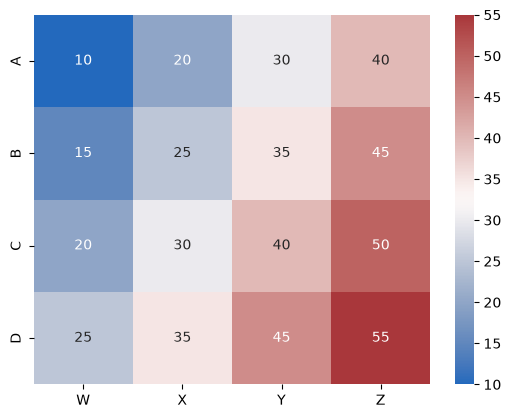

In [3]:
matrix=pd.DataFrame([[10,20,30,40],[15,25,35,45],[20,30,40,50],[25,35,45,55]], index=['A','B','C','D'], columns=['W','X','Y','Z'])

sns.heatmap(data=matrix,annot=True, cmap='vlag')

<Axes: >

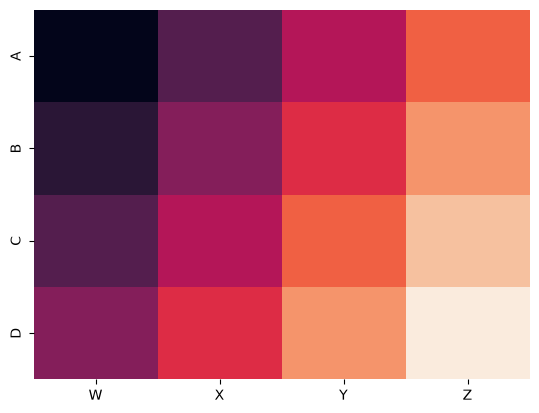

In [4]:
sns.heatmap(data=matrix,cbar=False)

<Axes: >

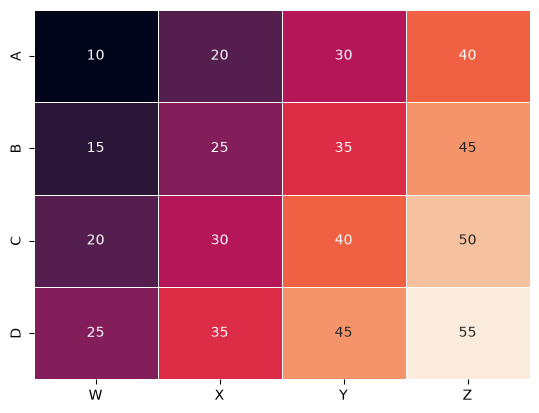

In [5]:
sns.heatmap(data=matrix,cbar=False, annot=True, linewidths=0.5) #annot숫자 cbar 옆에 바

In [6]:
matrix.to_numpy().min()   #10
matrix.to_numpy().max()   #55

np.int64(55)

<Axes: >

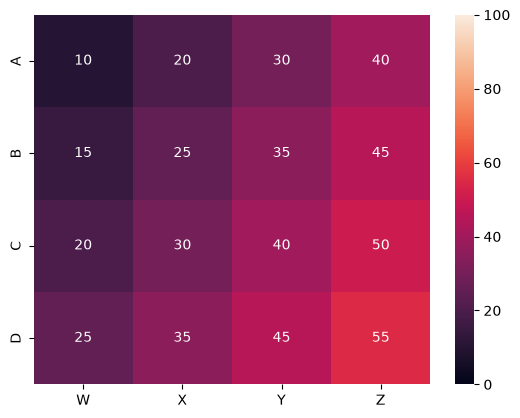

In [7]:
sns.heatmap(data=matrix, annot=True, vmin=0, vmax=100)

In [10]:
numeric_df=customer_df[['advertising','visitors','buyers','sales','satisfaction']]

numeric_df.head()






,advertising,visitors,buyers,sales,satisfaction
0,32.8,760,89,89.2,3.04
1,38.8,761,107,98.0,4.17
2,54.7,960,84,90.7,3.70
3,43.7,686,84,67.8,3.33
4,56.3,886,109,94.0,3.27


In [13]:
corr_matrix=numeric_df.corr()   #상관계수 행혈 생성

<Axes: >

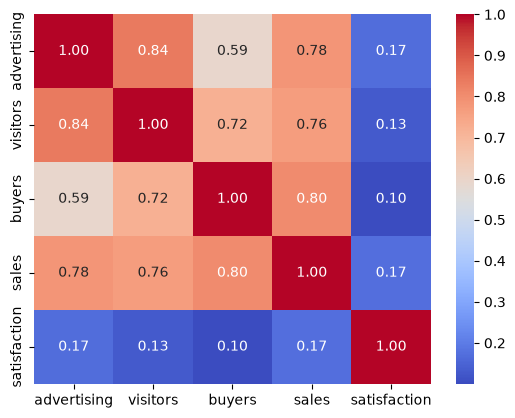

In [15]:
sns.heatmap(data=corr_matrix, annot=True,fmt='0.2f', cmap='coolwarm')

plt.show()



In [16]:
corr_matrix.loc['advertising','visitors']

np.float64(0.8411583081656948)

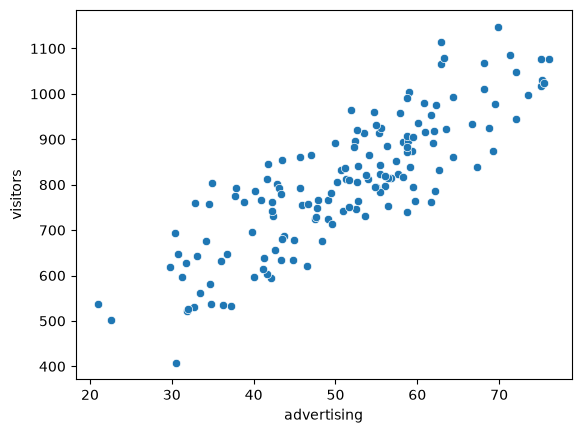

In [18]:
sns.scatterplot(data=customer_df, x='advertising', y='visitors')

plt.show()

In [21]:
mask = np.triu(np.ones_like(corr_matrix,dtype=bool))

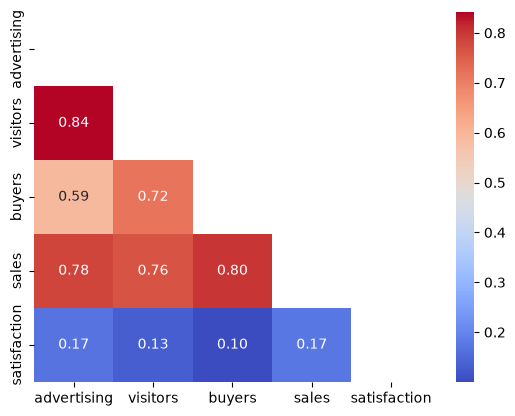

In [23]:
sns.heatmap(data=corr_matrix, mask=mask,cmap='coolwarm',annot=True,fmt='.2f')

plt.show()

In [ ]:
#pairplot
#여러수칭형 변수의 모든 조합을 행렬 형태로 표현


In [24]:
pair_df =customer_df[['advertising','visitors','buyers','sales']]

pair_df

,advertising,visitors,buyers,sales
0,32.8,760,89,89.2
1,38.8,761,107,98.0
2,54.7,960,84,90.7
3,43.7,686,84,67.8
4,56.3,886,109,94.0
...,...,...,...,...
145,49.4,781,122,106.6
146,43.1,793,95,75.6
147,43.4,779,111,91.6
148,55.0,931,105,90.9


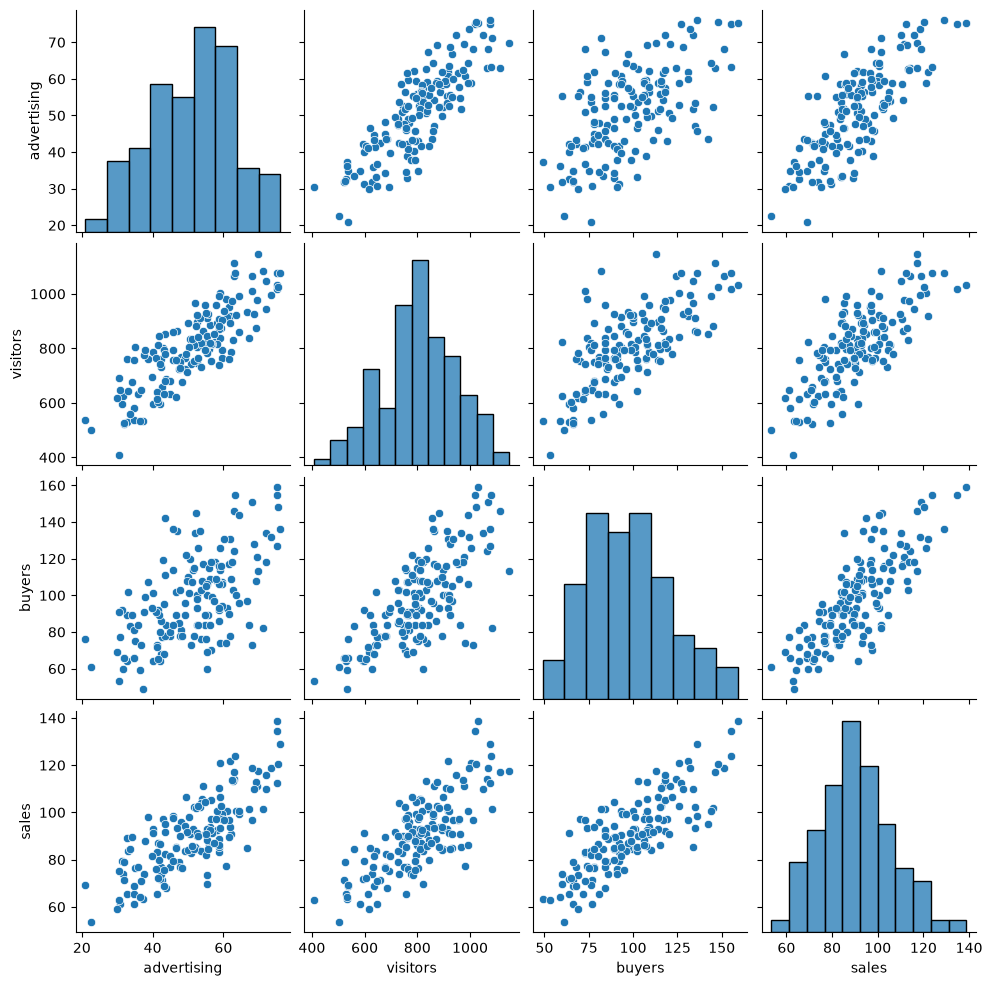

In [25]:
sns.pairplot(data=pair_df)

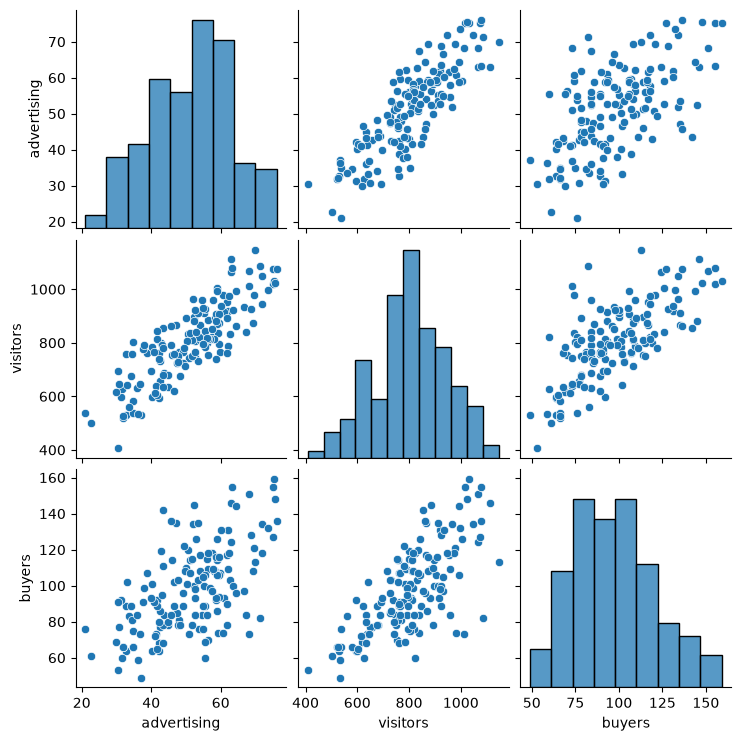

In [26]:
sns.pairplot(data=pair_df, vars=['advertising','visitors','buyers'])

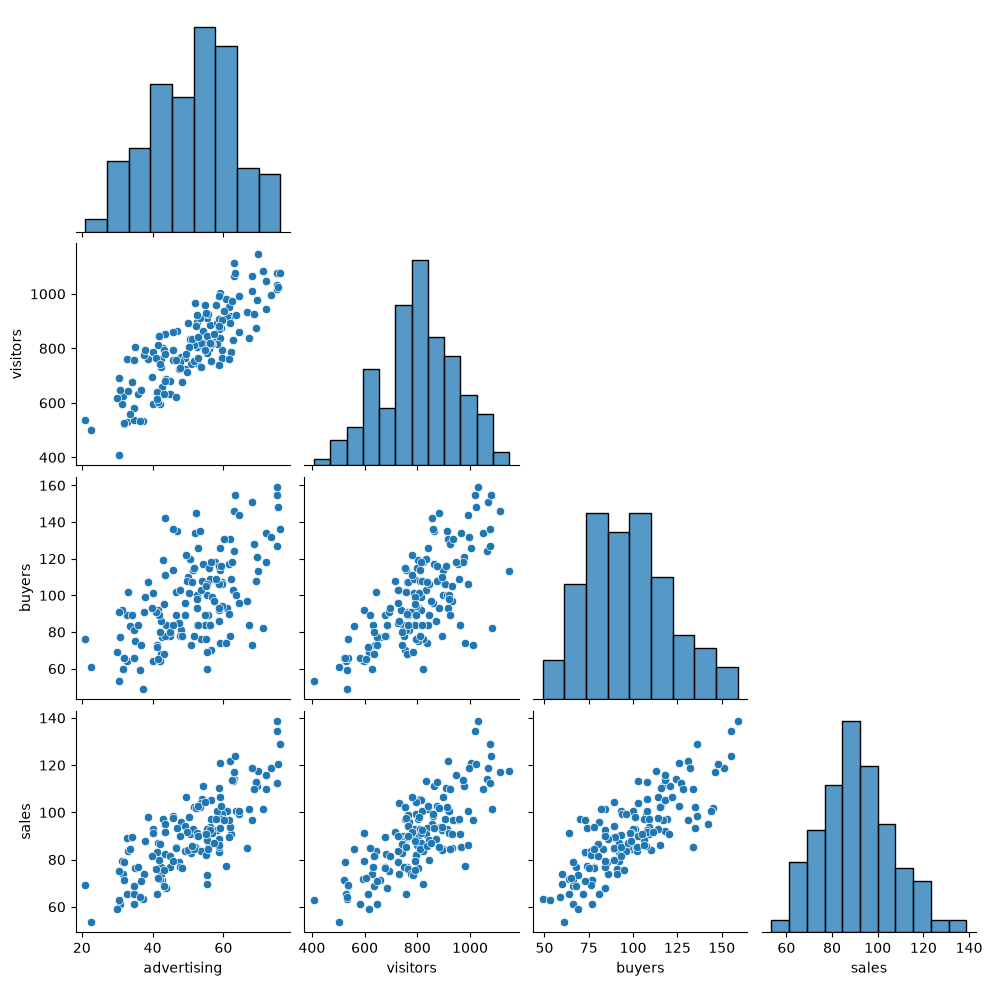

In [32]:
sns.pairplot(data=pair_df, corner=True)

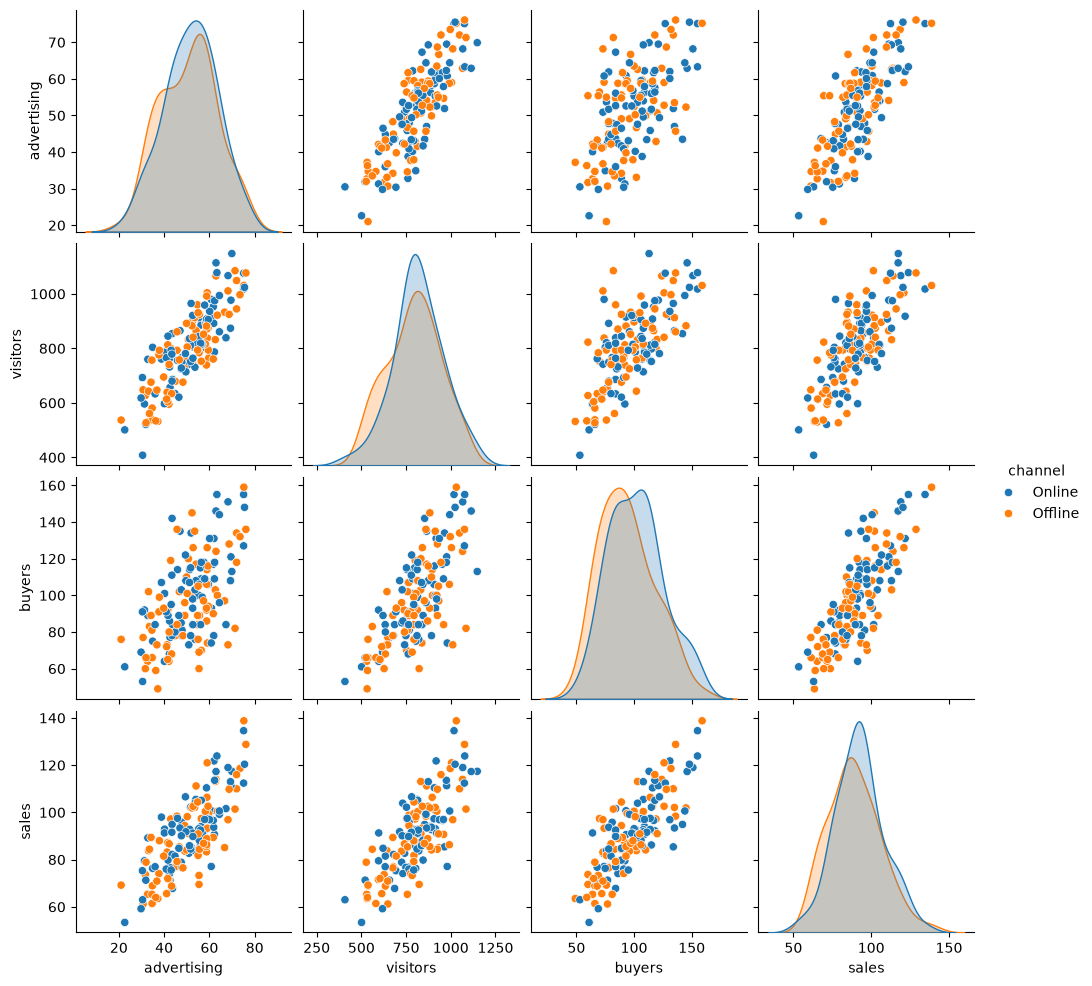

In [33]:
sns.pairplot(data=customer_df, vars=['advertising','visitors','buyers','sales'],hue='channel')